In [1]:
import pandas as pd

In [2]:
zhvi = pd.read_csv("../data/Metro_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv")

In [3]:
zhvi.shape

(895, 323)

In [4]:
zhvi.columns

Index(['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName',
       '2000-01-31', '2000-02-29', '2000-03-31', '2000-04-30', '2000-05-31',
       ...
       '2025-09-30', '2025-10-31', '2025-11-30', '2025-12-31', '2026-01-31',
       '2026-02-28', '2026-03-31', '2026-04-30', '2026-05-31', '2026-06-30'],
      dtype='str', length=323)

In [5]:
zhvi.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,...,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28,2026-03-31,2026-04-30,2026-05-31,2026-06-30
0,102001,0,United States,country,NaN,125206.997378,125427.276624,125700.455324,126286.370014,126960.687576,...,369475.972328,369920.427655,370612.174008,371421.454541,372193.561275,372924.337793,373426.328497,373507.545378,373242.049037,372995.192537
1,394913,1,"New York, NY",msa,NY,222017.778856,222961.229149,223913.417492,225842.919527,227840.985703,...,709628.293851,712004.813811,715405.757117,718885.828185,722003.180517,725638.840804,729493.235819,731943.853454,733495.479875,735003.128702
2,753899,2,"Los Angeles, CA",msa,CA,225885.767913,226726.349571,227845.996323,230073.717243,232510.145535,...,959296.407537,961759.656310,965141.641357,969178.618533,971757.837797,973013.669103,972673.281150,971019.676130,969535.332329,968028.188948
3,394463,3,"Chicago, IL",msa,IL,159015.886004,159163.088391,159443.437931,160140.877915,160979.814326,...,347637.905227,348990.073801,350593.897618,352389.170193,354068.029351,355878.069464,357334.820796,358370.099664,359004.083536,359887.600103
4,394514,4,"Dallas, TX",msa,TX,131742.629314,131801.307941,131868.765030,132043.944005,132274.912687,...,373911.443083,373551.625958,373279.474416,373054.749618,372607.263853,372013.540892,370924.767470,369570.718315,367967.779219,366701.488281


In [6]:
zhvi[zhvi["RegionName"].str.contains("Cleveland")]

,RegionID,SizeRank,RegionName,RegionType,StateName,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,...,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28,2026-03-31,2026-04-30,2026-05-31,2026-06-30
34,394475,35,"Cleveland, OH",msa,OH,121808.671097,121987.283217,122169.789043,122550.593574,123137.865382,...,248500.521318,249230.013552,250186.705347,251222.324056,252245.403853,253216.918528,254053.454974,254739.498734,255166.763725,255598.498594
324,394474,334,"Cleveland, TN",msa,TN,102604.340224,102715.652132,102801.593587,103025.317027,103304.614007,...,309780.942149,310871.193306,312340.884392,313555.864117,314610.932547,315399.638117,316132.533266,316680.984623,316905.681601,317005.001803
778,394473,806,"Cleveland, MS",msa,MS,NaN,NaN,NaN,NaN,NaN,...,125120.933871,124253.534329,123364.404121,122580.516612,122183.180126,122476.172653,123564.773215,123677.409690,122714.564186,120737.681522


In [7]:
zhvi[zhvi["RegionName"].str.contains("Columbus|Cincinnati|Indianapolis|Pittsburgh|Detroit|New York")]["RegionName"]

1          New York, NY
14          Detroit, MI
27       Pittsburgh, PA
28       Cincinnati, OH
32         Columbus, OH
33     Indianapolis, IN
155        Columbus, GA
432        Columbus, IN
526        Columbus, MS
755        Columbus, NE
Name: RegionName, dtype: str

In [8]:
metros = [
    "Cleveland, OH",
    "Columbus, OH",
    "Cincinnati, OH",
    "Indianapolis, IN",
    "Pittsburgh, PA",
    "Detroit, MI",
    "New York, NY"
]

In [9]:
zhvi_metros = zhvi[zhvi["RegionName"].isin(metros)]
zhvi_metros.shape

(7, 323)

In [10]:
zhvi_long = zhvi_metros.melt(
    id_vars=["RegionID", "SizeRank", "RegionName", "RegionType", "StateName"],
    var_name="date",
    value_name="home_value"
)
zhvi_long.shape

(2226, 7)

In [11]:
zhvi_long.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,date,home_value
0,394913,1,"New York, NY",msa,NY,2000-01-31,222017.778856
1,394532,14,"Detroit, MI",msa,MI,2000-01-31,127088.584728
2,394982,27,"Pittsburgh, PA",msa,PA,2000-01-31,91353.664520
3,394466,28,"Cincinnati, OH",msa,OH,2000-01-31,131773.477497
4,394492,32,"Columbus, OH",msa,OH,2000-01-31,130280.167512


In [12]:
zhvi_long.dtypes

RegionID        int64
SizeRank        int64
RegionName        str
RegionType        str
StateName         str
date              str
home_value    float64
dtype: object

In [13]:
zhvi_long["date"] = pd.to_datetime(zhvi_long["date"])
zhvi_long.dtypes

RegionID               int64
SizeRank               int64
RegionName               str
RegionType               str
StateName                str
date          datetime64[us]
home_value           float64
dtype: object

In [14]:
zhvi_long = zhvi_long[zhvi_long["date"] >= "2015-01-01"]
zhvi_long.shape

(966, 7)

In [15]:
zori = pd.read_csv("../data/Metro_zori_uc_sfr_sm_sa_month.csv")
zori.shape

(603, 143)

In [16]:
zori.columns[:8]

Index(['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName',
       '2015-01-31', '2015-02-28', '2015-03-31'],
      dtype='str')

In [17]:
zori_metros = zori[zori["RegionName"].isin(metros)]
zori_metros.shape

(7, 143)

In [18]:
zori_long = zori_metros.melt(
    id_vars=["RegionID", "SizeRank", "RegionName", "RegionType", "StateName"],
    var_name="date",
    value_name="rent"
)
zori_long["date"] = pd.to_datetime(zori_long["date"])
zori_long.shape

(966, 7)

In [19]:
zori_long["rent"].isna().sum()

np.int64(0)

In [20]:
zhvi_long["home_value"].isna().sum()

np.int64(0)

In [21]:
df = zhvi_long.merge(
    zori_long[["RegionName", "date", "rent"]],
    on=["RegionName", "date"]
)
df.shape

(966, 8)

In [22]:
df.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,date,home_value,rent
0,394913,1,"New York, NY",msa,NY,2015-01-31,418698.971508,2080.813646
1,394532,14,"Detroit, MI",msa,MI,2015-01-31,126328.184600,917.424707
2,394982,27,"Pittsburgh, PA",msa,PA,2015-01-31,142418.143598,1065.369438
3,394466,28,"Cincinnati, OH",msa,OH,2015-01-31,152902.512981,1084.805926
4,394492,32,"Columbus, OH",msa,OH,2015-01-31,156251.637089,1135.527710


In [23]:
sale_to_list = pd.read_csv("../data/Metro_median_sale_to_list_uc_sfrcondo_sm_month.csv")
sale_to_list.shape

(676, 104)

In [24]:
sale_to_list.columns[:8]

Index(['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName',
       '2018-03-31', '2018-04-30', '2018-05-31'],
      dtype='str')

In [25]:
stl_metros = sale_to_list[sale_to_list["RegionName"].isin(metros)]
stl_long = stl_metros.melt(
    id_vars=["RegionID", "SizeRank", "RegionName", "RegionType", "StateName"],
    var_name="date",
    value_name="sale_to_list"
)
stl_long["date"] = pd.to_datetime(stl_long["date"])
stl_long.shape

(693, 7)

In [26]:
stl_long["sale_to_list"].isna().sum()

np.int64(0)

In [27]:
df["gross_yield"] = (df["rent"] * 12) / df["home_value"]
df[["RegionName", "date", "gross_yield"]].head()

,RegionName,date,gross_yield
0,"New York, NY",2015-01-31,0.059637
1,"Detroit, MI",2015-01-31,0.087147
2,"Pittsburgh, PA",2015-01-31,0.089767
3,"Cincinnati, OH",2015-01-31,0.085137
4,"Columbus, OH",2015-01-31,0.087208


In [28]:
latest = df[df["date"] == df["date"].max()]
latest[["RegionName", "home_value", "rent", "gross_yield"]].sort_values("gross_yield", ascending=False)

,RegionName,home_value,rent,gross_yield
961,"Pittsburgh, PA",235538.505867,1719.651916,0.087611
965,"Cleveland, OH",255598.498594,1747.974321,0.082065
964,"Indianapolis, IN",297384.604762,1965.056518,0.079294
962,"Cincinnati, OH",313302.923398,2063.911293,0.079051
963,"Columbus, OH",335356.559709,2109.253663,0.075475
960,"Detroit, MI",271674.905042,1659.892434,0.073318
959,"New York, NY",735003.128702,3631.485227,0.059289


In [29]:
first = df[df["date"] == df["date"].min()][["RegionName", "home_value"]]
last = df[df["date"] == df["date"].max()][["RegionName", "home_value"]]
growth = first.merge(last, on="RegionName", suffixes=("_start", "_end"))
growth

,RegionName,home_value_start,home_value_end
0,"New York, NY",418698.971508,735003.128702
1,"Detroit, MI",126328.184600,271674.905042
2,"Pittsburgh, PA",142418.143598,235538.505867
3,"Cincinnati, OH",152902.512981,313302.923398
4,"Columbus, OH",156251.637089,335356.559709
5,"Indianapolis, IN",140487.069256,297384.604762
6,"Cleveland, OH",125030.262283,255598.498594


In [30]:
years = (df["date"].max() - df["date"].min()).days / 365.25
years

11.411362080766597

In [31]:
growth["cagr"] = (growth["home_value_end"] / growth["home_value_start"]) ** (1 / years) - 1
growth.sort_values("cagr", ascending=False)

,RegionName,home_value_start,home_value_end,cagr
1,"Detroit, MI",126328.184600,271674.905042,0.069404
4,"Columbus, OH",156251.637089,335356.559709,0.069217
5,"Indianapolis, IN",140487.069256,297384.604762,0.067924
3,"Cincinnati, OH",152902.512981,313302.923398,0.064883
6,"Cleveland, OH",125030.262283,255598.498594,0.064666
0,"New York, NY",418698.971508,735003.128702,0.050549
2,"Pittsburgh, PA",142418.143598,235538.505867,0.045075


In [32]:
df = df.sort_values(["RegionName", "date"])
df[["RegionName", "date", "home_value"]].head()

,RegionName,date,home_value
3,"Cincinnati, OH",2015-01-31,152902.512981
10,"Cincinnati, OH",2015-02-28,153353.550105
17,"Cincinnati, OH",2015-03-31,153802.242339
24,"Cincinnati, OH",2015-04-30,154301.425238
31,"Cincinnati, OH",2015-05-31,155021.140549


In [33]:
df["monthly_return"] = df.groupby("RegionName")["home_value"].pct_change()
df[["RegionName", "date", "home_value", "monthly_return"]].head()

,RegionName,date,home_value,monthly_return
3,"Cincinnati, OH",2015-01-31,152902.512981,NaN
10,"Cincinnati, OH",2015-02-28,153353.550105,0.002950
17,"Cincinnati, OH",2015-03-31,153802.242339,0.002926
24,"Cincinnati, OH",2015-04-30,154301.425238,0.003246
31,"Cincinnati, OH",2015-05-31,155021.140549,0.004664


In [34]:
volatility = df.groupby("RegionName")["monthly_return"].std() * (12 ** 0.5)
volatility.sort_values()

RegionName
New York, NY        0.010930
Cincinnati, OH      0.014408
Cleveland, OH       0.014438
Pittsburgh, PA      0.016040
Columbus, OH        0.016536
Detroit, MI         0.016612
Indianapolis, IN    0.017206
Name: monthly_return, dtype: float64

In [35]:
volatility.sort_values(ascending=False) / volatility.min()

RegionName
Indianapolis, IN    1.574252
Detroit, MI         1.519862
Columbus, OH        1.512947
Pittsburgh, PA      1.467575
Cleveland, OH       1.320978
Cincinnati, OH      1.318227
New York, NY        1.000000
Name: monthly_return, dtype: float64

In [36]:
stl_recent = stl_long[stl_long["date"] >= "2024-01-01"]
liquidity = stl_recent.groupby("RegionName")["sale_to_list"].mean()
liquidity.sort_values(ascending=False)

RegionName
New York, NY        1.001790
Columbus, OH        0.997348
Detroit, MI         0.996977
Cleveland, OH       0.996491
Cincinnati, OH      0.994518
Indianapolis, IN    0.990995
Pittsburgh, PA      0.987848
Name: sale_to_list, dtype: float64

In [37]:
summary = latest[["RegionName", "home_value", "gross_yield"]].copy()
summary

,RegionName,home_value,gross_yield
959,"New York, NY",735003.128702,0.059289
960,"Detroit, MI",271674.905042,0.073318
961,"Pittsburgh, PA",235538.505867,0.087611
962,"Cincinnati, OH",313302.923398,0.079051
963,"Columbus, OH",335356.559709,0.075475
964,"Indianapolis, IN",297384.604762,0.079294
965,"Cleveland, OH",255598.498594,0.082065


In [38]:
summary = summary.merge(growth[["RegionName", "cagr"]], on="RegionName")
summary

,RegionName,home_value,gross_yield,cagr
0,"New York, NY",735003.128702,0.059289,0.050549
1,"Detroit, MI",271674.905042,0.073318,0.069404
2,"Pittsburgh, PA",235538.505867,0.087611,0.045075
3,"Cincinnati, OH",313302.923398,0.079051,0.064883
4,"Columbus, OH",335356.559709,0.075475,0.069217
5,"Indianapolis, IN",297384.604762,0.079294,0.067924
6,"Cleveland, OH",255598.498594,0.082065,0.064666


In [39]:
vol_df = volatility.reset_index()
vol_df.columns = ["RegionName", "volatility"]
vol_df

,RegionName,volatility
0,"Cincinnati, OH",0.014408
1,"Cleveland, OH",0.014438
2,"Columbus, OH",0.016536
3,"Detroit, MI",0.016612
4,"Indianapolis, IN",0.017206
5,"New York, NY",0.010930
6,"Pittsburgh, PA",0.016040


In [40]:
summary = summary.merge(vol_df, on="RegionName")
summary

,RegionName,home_value,gross_yield,cagr,volatility
0,"New York, NY",735003.128702,0.059289,0.050549,0.010930
1,"Detroit, MI",271674.905042,0.073318,0.069404,0.016612
2,"Pittsburgh, PA",235538.505867,0.087611,0.045075,0.016040
3,"Cincinnati, OH",313302.923398,0.079051,0.064883,0.014408
4,"Columbus, OH",335356.559709,0.075475,0.069217,0.016536
5,"Indianapolis, IN",297384.604762,0.079294,0.067924,0.017206
6,"Cleveland, OH",255598.498594,0.082065,0.064666,0.014438


In [41]:
liq_df = liquidity.reset_index()
liq_df.columns = ["RegionName", "sale_to_list"]
summary = summary.merge(liq_df, on="RegionName")
summary

,RegionName,home_value,gross_yield,cagr,volatility,sale_to_list
0,"New York, NY",735003.128702,0.059289,0.050549,0.010930,1.001790
1,"Detroit, MI",271674.905042,0.073318,0.069404,0.016612,0.996977
2,"Pittsburgh, PA",235538.505867,0.087611,0.045075,0.016040,0.987848
3,"Cincinnati, OH",313302.923398,0.079051,0.064883,0.014408,0.994518
4,"Columbus, OH",335356.559709,0.075475,0.069217,0.016536,0.997348
5,"Indianapolis, IN",297384.604762,0.079294,0.067924,0.017206,0.990995
6,"Cleveland, OH",255598.498594,0.082065,0.064666,0.014438,0.996491


In [42]:
print("Yield-focused:      ", summary.loc[summary["gross_yield"].idxmax(), "RegionName"])
print("Appreciation-focused:", summary.loc[summary["cagr"].idxmax(), "RegionName"])
print("Risk-averse:        ", summary.loc[summary["volatility"].idxmin(), "RegionName"])

Yield-focused:       Pittsburgh, PA
Appreciation-focused: Detroit, MI
Risk-averse:         New York, NY


In [43]:
summary["yield_per_risk"] = summary["gross_yield"] / summary["volatility"]
summary["cagr_per_risk"] = summary["cagr"] / summary["volatility"]
summary[["RegionName", "yield_per_risk", "cagr_per_risk"]].sort_values("yield_per_risk", ascending=False)

,RegionName,yield_per_risk,cagr_per_risk
6,"Cleveland, OH",5.683962,4.478898
3,"Cincinnati, OH",5.486638,4.503255
2,"Pittsburgh, PA",5.461957,2.810089
0,"New York, NY",5.424567,4.624850
5,"Indianapolis, IN",4.608421,3.947614
4,"Columbus, OH",4.564238,4.185809
1,"Detroit, MI",4.413633,4.178027


In [44]:
summary.to_csv("../data/summary_metrics.csv", index=False)

In [45]:
import matplotlib.pyplot as plt

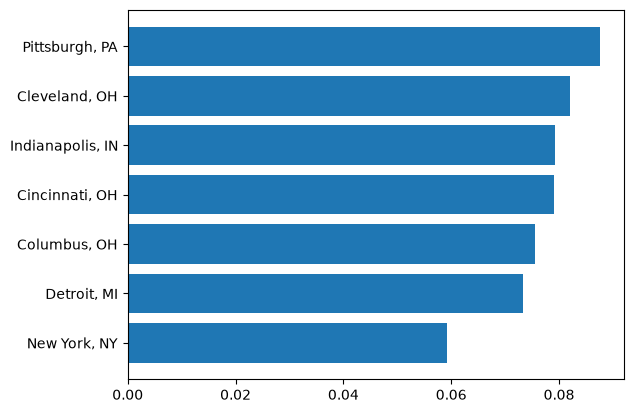

In [46]:
plot_data = summary.sort_values("gross_yield")
plt.barh(plot_data["RegionName"], plot_data["gross_yield"])
plt.show()

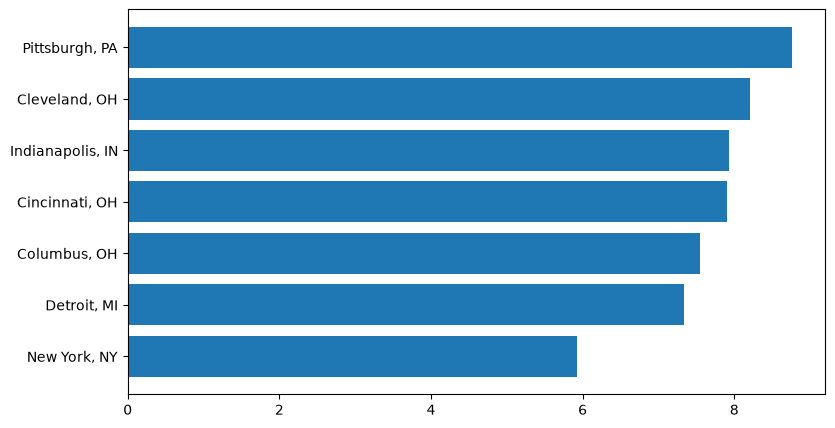

In [47]:
plt.figure(figsize=(9, 5))
plt.barh(plot_data["RegionName"], plot_data["gross_yield"] * 100)
plt.show()

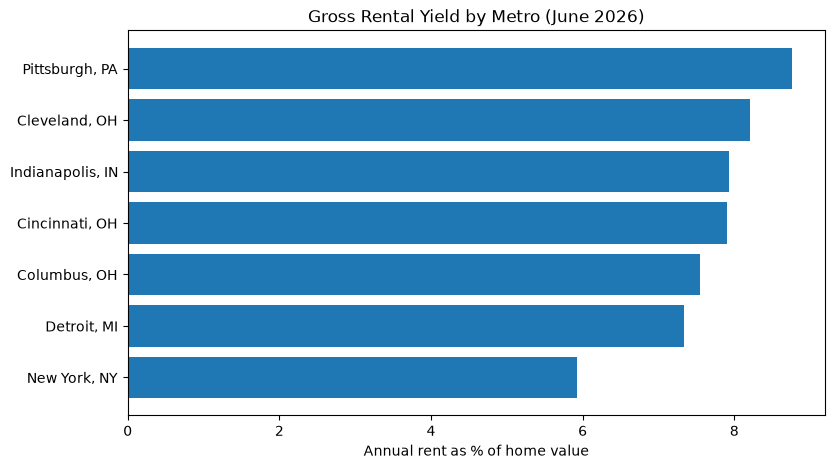

In [48]:
plt.figure(figsize=(9, 5))
plt.barh(plot_data["RegionName"], plot_data["gross_yield"] * 100)
plt.title("Gross Rental Yield by Metro (June 2026)")
plt.xlabel("Annual rent as % of home value")
plt.show()

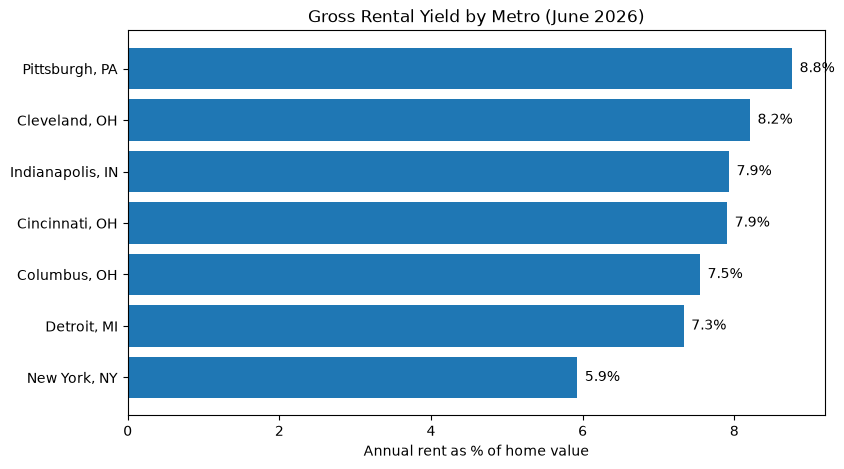

In [49]:
plt.figure(figsize=(9, 5))
bars = plt.barh(plot_data["RegionName"], plot_data["gross_yield"] * 100)
plt.title("Gross Rental Yield by Metro (June 2026)")
plt.xlabel("Annual rent as % of home value")

for bar in bars:
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f"{bar.get_width():.1f}%", va="center")

plt.show()

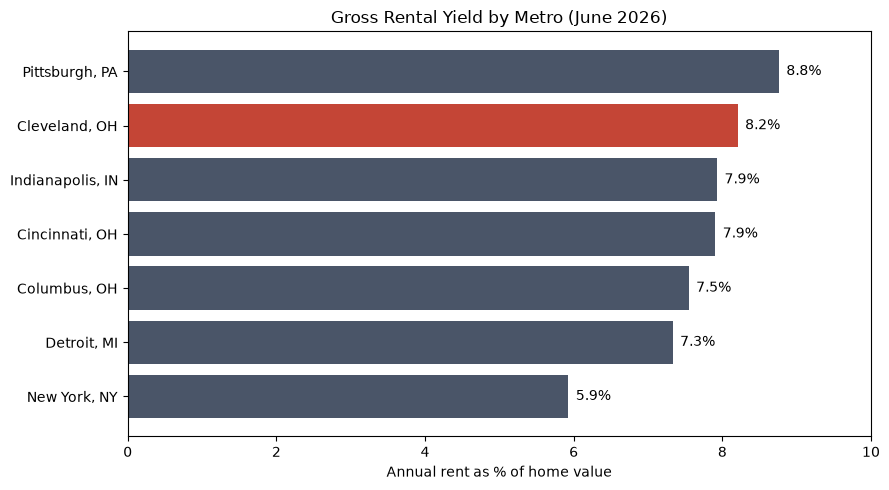

In [50]:
colors = ["#c44536" if m == "Cleveland, OH" else "#4a5568" for m in plot_data["RegionName"]]

plt.figure(figsize=(9, 5))
bars = plt.barh(plot_data["RegionName"], plot_data["gross_yield"] * 100, color=colors)
plt.title("Gross Rental Yield by Metro (June 2026)")
plt.xlabel("Annual rent as % of home value")
plt.xlim(0, 10)

for bar in bars:
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f"{bar.get_width():.1f}%", va="center")

plt.tight_layout()
plt.show()

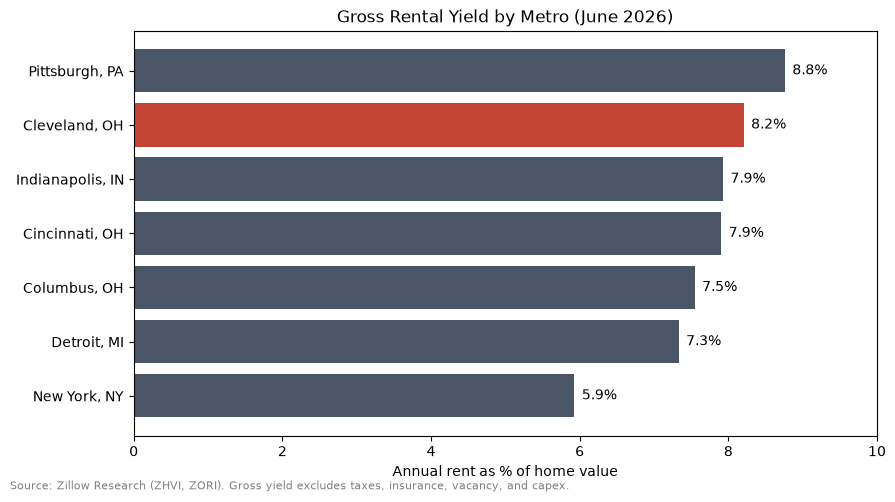

In [51]:
plt.figure(figsize=(9, 5))
bars = plt.barh(plot_data["RegionName"], plot_data["gross_yield"] * 100, color=colors)
plt.title("Gross Rental Yield by Metro (June 2026)")
plt.xlabel("Annual rent as % of home value")
plt.xlim(0, 10)

for bar in bars:
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f"{bar.get_width():.1f}%", va="center")

plt.figtext(0.01, 0.01, "Source: Zillow Research (ZHVI, ZORI). Gross yield excludes taxes, insurance, vacancy, and capex.",
            fontsize=8, color="grey")

plt.tight_layout()
plt.savefig("../charts/yield_by_metro.png", dpi=150, bbox_inches="tight")
plt.show()

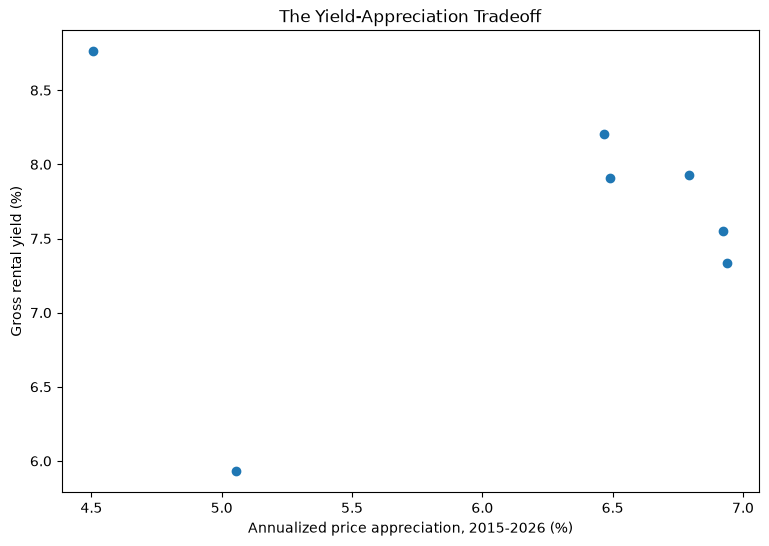

In [52]:
plt.figure(figsize=(9, 6))
plt.scatter(summary["cagr"] * 100, summary["gross_yield"] * 100)
plt.xlabel("Annualized price appreciation, 2015-2026 (%)")
plt.ylabel("Gross rental yield (%)")
plt.title("The Yield-Appreciation Tradeoff")
plt.show()

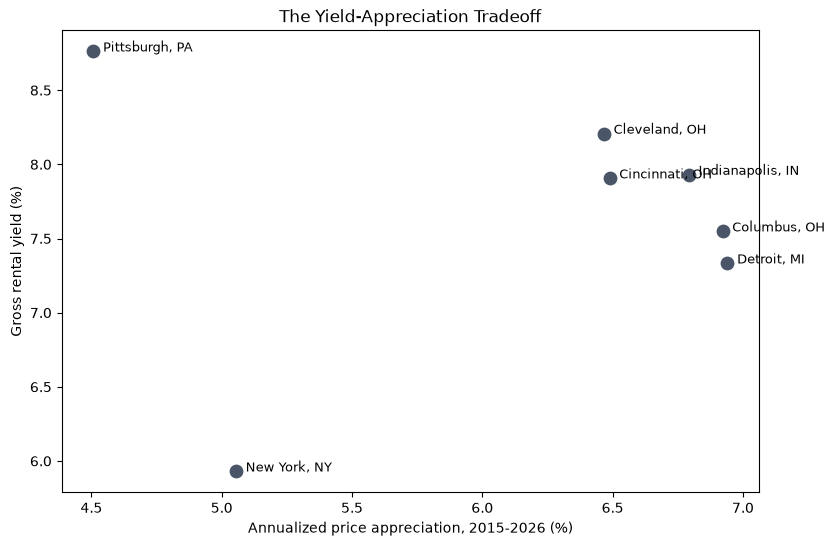

In [53]:
plt.figure(figsize=(9, 6))
plt.scatter(summary["cagr"] * 100, summary["gross_yield"] * 100, s=80, color="#4a5568")

for i, row in summary.iterrows():
    plt.annotate(row["RegionName"],
                 (row["cagr"] * 100, row["gross_yield"] * 100),
                 xytext=(7, 0), textcoords="offset points", fontsize=9)

plt.xlabel("Annualized price appreciation, 2015-2026 (%)")
plt.ylabel("Gross rental yield (%)")
plt.title("The Yield-Appreciation Tradeoff")
plt.show()

In [54]:
summary["short_name"] = summary["RegionName"].str.split(",").str[0]
summary[["RegionName", "short_name"]]

,RegionName,short_name
0,"New York, NY",New York
1,"Detroit, MI",Detroit
2,"Pittsburgh, PA",Pittsburgh
3,"Cincinnati, OH",Cincinnati
4,"Columbus, OH",Columbus
5,"Indianapolis, IN",Indianapolis
6,"Cleveland, OH",Cleveland


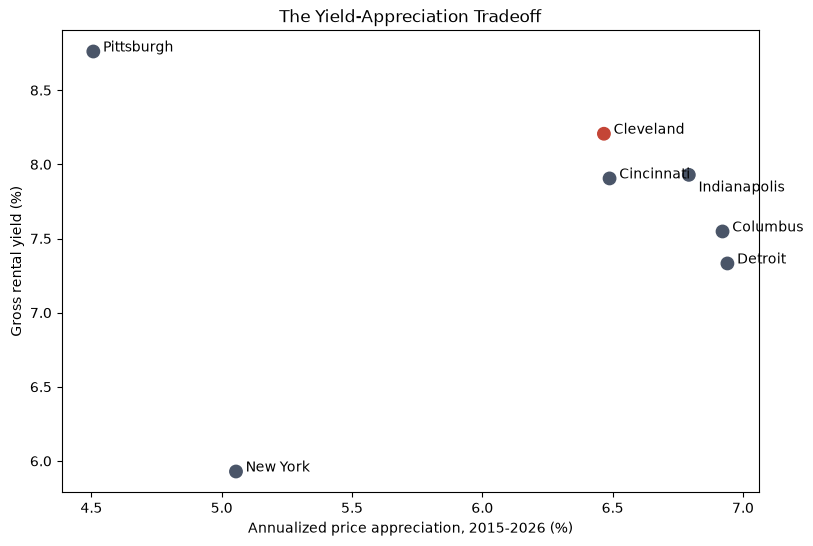

In [55]:
plt.figure(figsize=(9, 6))

colors = ["#c44536" if m == "Cleveland" else "#4a5568" for m in summary["short_name"]]
plt.scatter(summary["cagr"] * 100, summary["gross_yield"] * 100, s=80, color=colors)

for i, row in summary.iterrows():
    offset = (7, -12) if row["short_name"] == "Indianapolis" else (7, 0)
    plt.annotate(row["short_name"],
                 (row["cagr"] * 100, row["gross_yield"] * 100),
                 xytext=offset, textcoords="offset points", fontsize=10)

plt.xlabel("Annualized price appreciation, 2015-2026 (%)")
plt.ylabel("Gross rental yield (%)")
plt.title("The Yield-Appreciation Tradeoff")
plt.show()

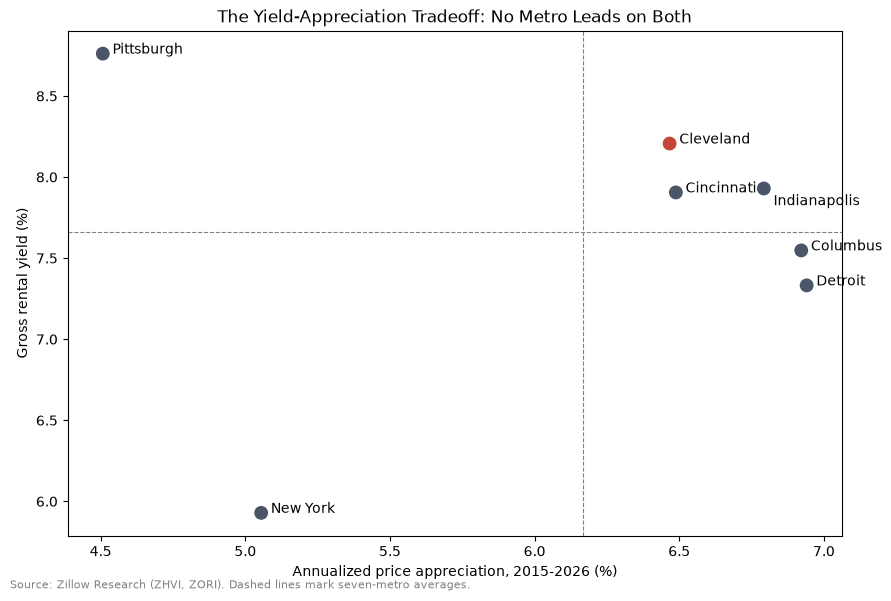

In [56]:
plt.figure(figsize=(9, 6))

plt.scatter(summary["cagr"] * 100, summary["gross_yield"] * 100, s=80, color=colors)

for i, row in summary.iterrows():
    offset = (7, -12) if row["short_name"] == "Indianapolis" else (7, 0)
    plt.annotate(row["short_name"],
                 (row["cagr"] * 100, row["gross_yield"] * 100),
                 xytext=offset, textcoords="offset points", fontsize=10)

plt.axhline(summary["gross_yield"].mean() * 100, color="grey", linestyle="--", linewidth=0.8)
plt.axvline(summary["cagr"].mean() * 100, color="grey", linestyle="--", linewidth=0.8)

plt.xlabel("Annualized price appreciation, 2015-2026 (%)")
plt.ylabel("Gross rental yield (%)")
plt.title("The Yield-Appreciation Tradeoff: No Metro Leads on Both")
plt.figtext(0.01, 0.01, "Source: Zillow Research (ZHVI, ZORI). Dashed lines mark seven-metro averages.",
            fontsize=8, color="grey")

plt.tight_layout()
plt.savefig("../charts/yield_vs_appreciation.png", dpi=150, bbox_inches="tight")
plt.show()